El algoritmo de Máquinas de Soporte Vectorial (SVM, por sus siglas en inglés, Support Vector Machine) es un método de aprendizaje supervisado utilizado para la clasificación y regresión. Su objetivo principal es encontrar un hiperplano óptimo que pueda separar de manera eficiente las muestras de diferentes clases en un espacio multidimensional.

<img src="svm.png">

Para explicar el algoritmo de SVM es necesario retroceder y entender algunos conceptos previos
###### Fuente:(TileStats)

La ecuación general de la recta se define como 

$Ax + By + C = 0$

una recta expresada con la ecuación general podemos transformarla a la notación que hemos usado (Recordar recta de regresión) con la siguiente expresión

y= $\frac{-A}{B}X + \frac{-C}{B} $

Para definir el hiperplano de separación que buscamos encontrar necesitamos utilizar la notación de la ecuación general


<img src="ecuaciondelarecta.png">

$Ax + By + C = 0$

Si incrementamos los valores de A entonces la pendiente se reduce
<img src="variacion A.png">

Si bajamos los valores de C el intercepto crece
<img src="variacionC.png">

si bajamos los valores de B el intercepto y la pendiente bajan (tiene efecto en ambas)

<img src="variacionB.png">

si sustituimos un punto en la ecuación general nos dirá de que lado de la recta se encuentra (positivo está arriba)
negativo (está abajo)
<img src="evalaciondelpunto.png">

si cambiamos la igualdad en las ecuaciones tenemos la recta conservando la pendiente pero desplazamos los interceptos
<img src="rectasparalelas.png">

si multiplicamos por una constante positiva los interceptos incrementan y se separan (por un negativo decrementan y se juntan)
<img src="multconstante.png">

la distancia de un punto a la recta se defina como
<img src="distanciapuntorecta.png">

la distancia entre dos rectas paralelas se define como
<img src="distanciarectas.png">

para el siguiente conjunto de datos se muestra el mejor hiperplano para clasificar. Si hay una observación nueva y está debajo se clasifica B, si está arriba será A
<img src="prediccionsvm.png">

podriamos tener esta otra recta. En el conjunto de entrenamiento funciona bien , ya que clasifica bien todos los casos
sin embargo para una observacion nueva podría predecir como clase A un individuo que es mas similar a la clase B
<img src="malhiperplano.png">

Para un hiperplano optimo tendremos dos lineas paralelas que tocan los puntos más cercanos al hiperplano, a estos puntos se le llaman
"support vectors" (Tambien se les llama puntos frontera) y la distancia entre los support vectors y el hiperplano optimo se llamará margen
<img src="supportvectors.png">

Podemos expresar las mismas rectas normalizadas. De forma que estas sean iguales a 1,0-1. Notemos que son las mismas rectas pero expresadas de distinta manera

<img src="hiperplanos normalizados.png">

En SVM las clases que buscamos clasificar se modifican por los valores 1 y -1 en lugar de 1 y 0, esto debido a la construcción que llevamos al momento. De esta forma la clasificación dependerá si el resultado de evaluar un punto en el hiperplano es positivo o negativo
<img src="modificacionYsvm.png">

recordamos que buscamos maximizar la distancia entre los puntos frontera y el hiperplano de separación.
La distancia de dos rectas paralelas está denotado por:
$ d= \frac{|C_2-C_1|}{\sqrt{A^2+B^2}} $

Pero como hemos normalizado las rectas esto es equivalente a 

$ d= \frac{2}{\sqrt{A^2+B^2}} $

y como sabemos que $w$ es un vector en terminos de A y B entonces tenemos la siguiente equivalencia

$ d= \frac{2}{||w||} $

Otra forma de verlo es que la distancia del punto frontera de la clase A y la Clase B al hiperplano será de 

$ z= \frac{1}{||w||} $

de esta forma 
$ d= \frac{1}{||w||} + \frac{1}{||w||}= \frac{2}{||w||}$

así buscamos maximizar la función 
$ \frac{2}{||w||}$
lo cual es equivalente a minimizar $||w||$

a la distancia entre la línea de separación (o hiperplano) y los puntos más cercanos de cada clase (puntos frontera o vector supports) se le llama $margen$

<img src="margen.png">

debemos agregar la siguiente condición a la función que queremos minimizar para que el margen no sea tan largo

$ max \frac{2}{||w||}$ tal que $ w^Tx + b >= 1$ si $Y=1$ y $ w^Tx + b <= 1$ si $Y= -1  $ 

esta condición hace que el margen no vaya más allá de los puntos frontera

la expresión anterior es equivalente a la siguiente

$max \frac{2}{||w||}$ tal que $ Y_i(w^Tx + b) >= 1$

ya que si evaluamos cualquier punto en la recta $-.5x+.5y+b>=1$

si tuvieramos una observación atípica que pertenece a un grupo pero se parece más al otro, entonces nuestra función de maximización cambia
<img src="softmargin.png">

donde $\epsilon$ es conocido como variable slack y representa la distnacia entre la observación y su correspondiente support vector. Los puntos que estén en el lugar incorrecto del hiperplano tendrán una distancia mayor a 1, mientras que los que están del lado correcto tendrán una distancia entre 0 y 1. Si los puntos están detrás de los support vectors entonces el valor de epsilon es cero.


Por otra parte $C$ es un hiperparametro de penalización que controla el peso que se le da a los puntos que no están bien clasificados. Un valor chico de C implica un margen largo y un valor grande C implica un margen pequeño (Recordar Lasso en regresión lineal) Un valor grande de C puede conducir a sobreajuste. El hiperparámetro, al igual otros que hemos revisado en otros modelos , se puede ajsutar con validación cruzada

<img src="Cgrande.png">

de esta forma la condición del problema de minimización es 

$min \frac{1}{2}||w||^2 + C\sum_{i=1}^n \epsilon_i$ tal que $ Y_i(w^Tx + b) >= 1 - \epsilon_i$

ya que maximizar $\frac{1}{||w||}$ es equivalente a minimizar $||w||^2$ y por lo tanto no afecta multiplicar $\frac{1}{2}$

Existen casos en los que una linea no podrá separar los datos.

<img src="kerneltrick.png">


En estos casos podemos aplicar el truco del $kernel$ Consiste en mapear los datos originales a un espacio de características de mayor dimensión donde la separación lineal es posible.

Por ejemplo, supongamos que tenemos puntos de datos bidimensionales que no son linealmente separables. Podemos usar una función del kernel para transformar los puntos de datos en un espacio tridimensional donde son linealmente separables. En el espacio tridimensional, podemos encontrar un hiperplano que separa los puntos de datos de manera efectiva. Sin embargo, no tenemos que calcular las coordenadas de los puntos de datos transformados explícitamente. En su lugar, usamos la función del kernel para calcular el producto punto entre los puntos de datos transformados. Esto se llama truco del kernel porque nos permite encontrar la solución en el espacio de mayor dimensión sin calcular las coordenadas de los puntos de datos transformados.

En resumen, el truco del kernel es una función matemática que nos permite transformar puntos de datos en un espacio de mayor dimensión donde son linealmente separables. Esta transformación nos permite encontrar un hiperplano que separa los puntos de datos de manera efectiva. El truco del kernel se llama truco porque nos permite encontrar la solución en el espacio de mayor dimensión sin calcular las coordenadas de los puntos de datos transformados.


Donde $K(x,y)=\langle \phi(x), \phi(y) \rangle$ es el llamado kernel, algunos ejemplos de estos son:
1. Polinomial $K(x,y)=\left(\langle x,y \rangle+a\right)^r$
2. Sigmoide $K(x,y)=tanh \left(a\langle x,y \rangle+a\right)$
3. Gausiana $K(x,y)=\exp \left(-|| x-y||^2/2\sigma^2 \right)$



## Algunos ejemplos de funciones Kernel:
**Kernel lineal**:
El kernel lineal es la función de kernel más simple, y se utiliza cuando los puntos de datos ya son linealmente separables. Simplemente calcula el producto punto entre dos puntos de datos en su espacio de características original:

$$K(\mathbf{x}_i, \mathbf{x}_j) = \mathbf{x}_i^T \mathbf{x}_j$$

**Kernel polinómico**:
El kernel polinómico se utiliza cuando los puntos de datos no son linealmente separables y requieren una función polinómica de grado superior para separarlos. Se define como:

$$K(\mathbf{x}_i, \mathbf{x}_j) = (\gamma\mathbf{x}_i^T \mathbf{x}_j + r)^d$$

donde $d$ es el grado del polinomio, $\gamma$ es un factor de escala y $r$ es un término constante.

**Kernel gaussiano (RBF)**:
El kernel gaussiano, también conocido como kernel de función de base radial (RBF), es una función de kernel comúnmente utilizada en SVM. Se define como:

$$K(\mathbf{x}_i, \mathbf{x}_j) = e^{-\gamma|\mathbf{x}_i - \mathbf{x}_j|^2}$$

donde $\gamma$ es un factor de escala que controla la anchura del kernel. El kernel gaussiano mapea los puntos de datos en un espacio de características que le permite capturar relaciones no lineales complejas entre los puntos de datos.

**Kernel sigmoide**:
El kernel sigmoide es una función de kernel popular para problemas de clasificación binaria. Se define como:

$$K(\mathbf{x}_i, \mathbf{x}_j) = \tanh(\gamma\mathbf{x}_i^T \mathbf{x}_j + r)$$

donde $\gamma$ y $r$ son términos de escala y constantes, respectivamente.



### Mi definición favorita: 

Un kernel es una función que devuelve el resultado de un producto punto realizado en otro espacio, 
proyectando implícitamente la información a un espacio de características de mayor dimensión.


# GLOSARIO:
- #### SVM (Support Vector Machine):

Una máquina de aprendizaje supervisado utilizada para la clasificación y regresión. SVM busca encontrar un hiperplano en un espacio de características que mejor separe dos clases.

- #### Hiperplano:

Un subespacio de dimensión d−1 en un espacio de d-dimensiones que se utiliza para separar dos clases en SVM. Es representado por una ecuación lineal y es el resultado del proceso de entrenamiento de SVM.

- #### Vector de Soporte:

Los puntos de datos más cercanos al hiperplano de decisión. Estos puntos son fundamentales para la construcción del hiperplano y determinan la posición y orientación del mismo.

- #### Margen:

La distancia entre el hiperplano y los puntos de datos más cercanos de las clases respectivas. En SVM, se busca maximizar este margen para mejorar la generalización del modelo.

- #### Max Margen (Máximo Margen):

El objetivo principal de SVM es encontrar el hiperplano que maximice la distancia entre las clases, es decir, maximizar el margen entre el hiperplano y los vectores de soporte más cercanos.

- ####  Margen Suave:

En SVM, un enfoque que permite cierto grado de error en la clasificación al introducir variables de holgura (slack variables). Esto se hace para manejar datos que no son linealmente separables y permitir cierta flexibilidad en la clasificación.

- #### Slack Variable (Variable de Holgura ):

Introducida en SVM para permitir ciertos errores en la clasificación. Cada variable de holgura representa el grado en que un punto de datos puede violar la restricción de clasificación correcta. Controla el equilibrio entre tener un margen más grande y permitir clasificaciones incorrectas. Se expresa como $epsilon$

- #### Hiperparámetro C:

Un hiperparámetro de regularización en SVM que controla el equilibrio entre maximizar el margen y minimizar las clasificaciones incorrectas. Un valor más alto de C da más peso a la clasificación correcta, mientras que un valor más bajo permite una mayor flexibilidad en la clasificación incorrecta.

- #### Kernel: 

Una función matemática utilizada en SVM para transformar el espacio de características original en un espacio de características de mayor dimensión. Los kernels permiten a SVM manejar datos no linealmente separables al realizar una transformación no lineal, lo que facilita la separación de clases en dimensiones superiores. Ejemplos comunes de kernels incluyen el kernel lineal, el kernel polinómico y el kernel gaussiano (RBF). Los kernels juegan un papel crucial en la capacidad de SVM para realizar clasificaciones no lineales.

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from numpy.random import randn,seed
from scipy.optimize import minimize
from sklearn.datasets import make_moons, make_biclusters
from sklearn.svm import SVC
from sklearn.svm import SVR
import sys
from sklearn.model_selection import GridSearchCV
sys.path.append("../files")
from sklearn.datasets import make_blobs
import utils 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler



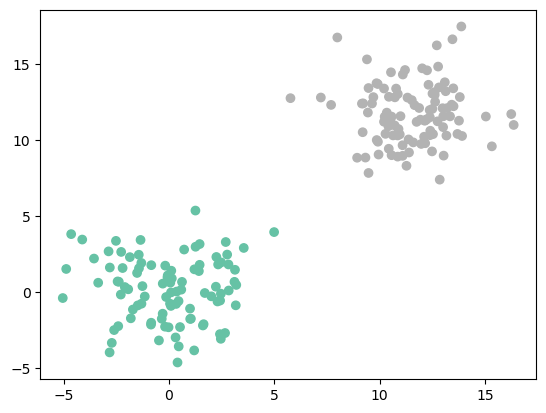

In [4]:
### creamos un set de datos sinteticos de dos clases
X, y, col= make_biclusters((200,2),2,noise=2,random_state=1643)
y=y[0]*2-1 # trues a 1 y -1
plt.scatter(*X.T,c=y,cmap="Set2")  # graficamos

In [5]:
svm=SVC(kernel="linear")
svm.fit(X,y)

SVC(kernel='linear')

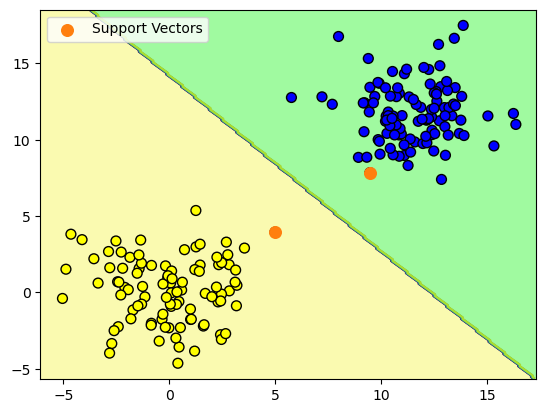

In [6]:
fig,ax=plt.subplots()
utils.plot_classf_model(X,y,svm,ax,step=.1,epsilon=1,contour=True)
plt.scatter(*svm.support_vectors_.T,c="tab:orange",label="Support Vectors",s=70)
plt.legend()

### Soft Margin

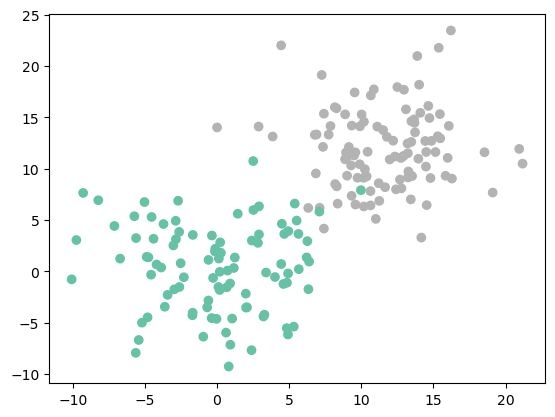

In [7]:
##metemos mas ruido a la base
X, y, cols= make_biclusters((200,2),2,noise=4,random_state=1643)
y=y[0]*2-1
plt.scatter(*X.T,c=y,cmap="Set2")

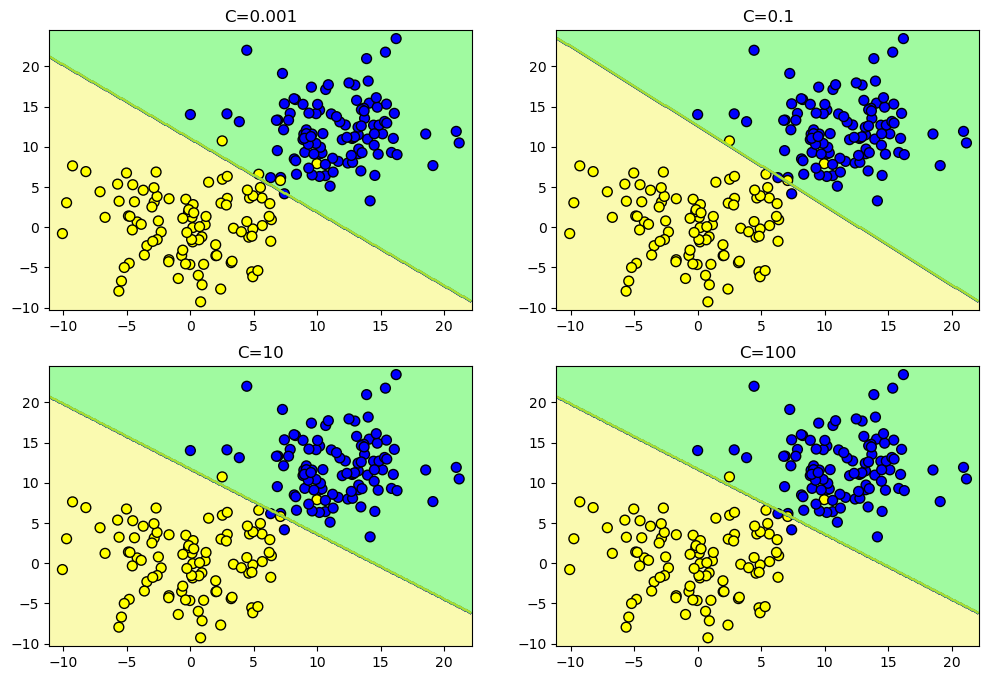

In [8]:
fig,ax=plt.subplots(2,2,figsize=(12,8))
ax=ax.ravel()
C=[.001,.1,10,100]
for axi, Ci in zip(ax,C):
    svm=SVC(C=Ci,kernel="linear")
    svm.fit(X,y)
    utils.plot_classf_model(X,y,svm,axi,step=0.1,epsilon=1,contour=True)
    axi.set_title(f"C={Ci}")

### vemos que mientras incrementamos C entonces permitimos menos el error
### con C=.0001 somos mas felxibles y tenemos 4 puntos amarillos en la parte de arriba
### con C=100

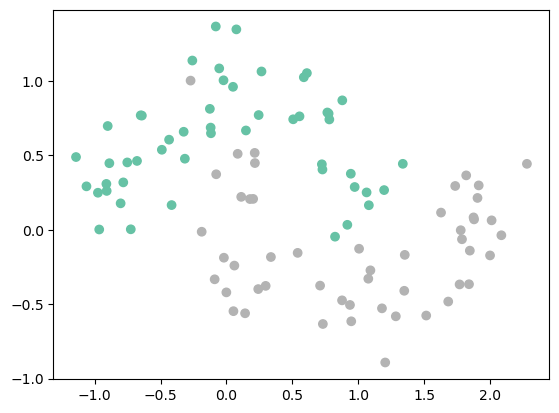

In [9]:
# metemos mas ruido para usar el truco del kernel
X,y=make_moons(100,noise=0.2,random_state=2718)
plt.scatter(*X.T,c=y,cmap="Set2")

In [10]:
### hacemos validación cruzada para escoger el mejor kernel y el mejor C

params={
    "kernel":["linear","poly","rbf","sigmoid"],
    "C":[.01,.1,1,10]
}
best_model=GridSearchCV(SVC(),params,scoring="accuracy")
best_model.fit(X,y)

GridSearchCV(estimator=SVC(),
             param_grid={'C': [0.01, 0.1, 1, 10],
                         'kernel': ['linear', 'poly', 'rbf', 'sigmoid']},
             scoring='accuracy')

In [11]:
best_model.best_score_ ### tenemos un accuracy de .96, muy bueno para un conjunto de datos traslapado

0.96

In [12]:
best_model.best_estimator_.kernel

'rbf'

In [13]:
best_model.best_estimator_.C

10

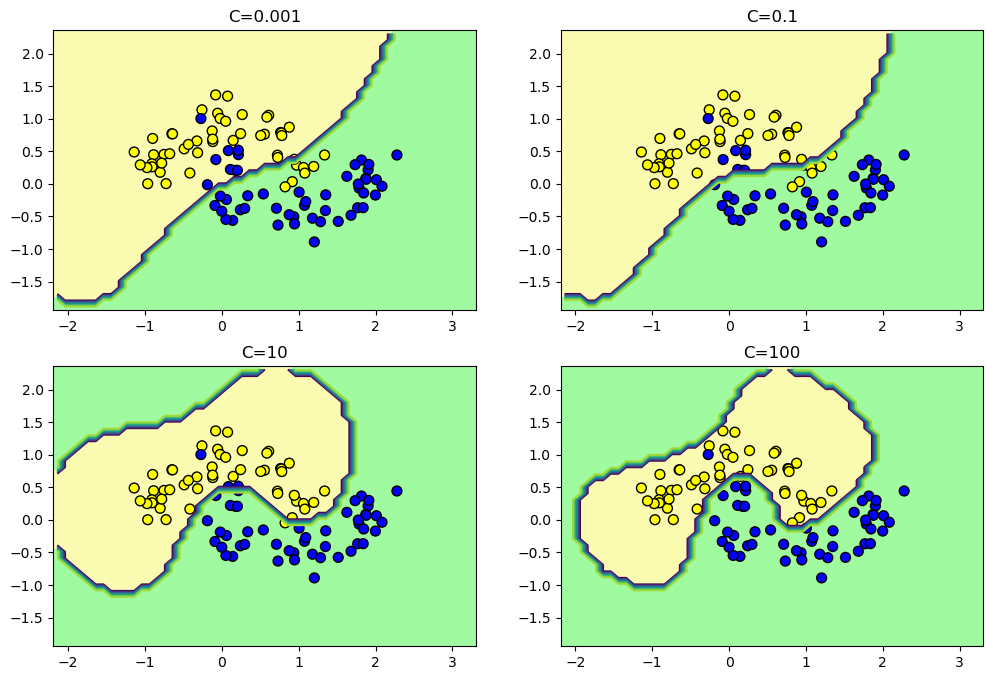

In [14]:
##### el caso del grafico con C=10 fue el que obtuvo los mejores resultados
fig,ax=plt.subplots(2,2,figsize=(12,8))
ax=ax.ravel()
C=[.001,.1,10,100]
for axi, Ci in zip(ax,C):
    svm=SVC(C=Ci,kernel="rbf")
    svm.fit(X,y)
    utils.plot_classf_model(X,y,svm,axi,step=0.1,epsilon=1,contour=True)
    axi.set_title(f"C={Ci}")

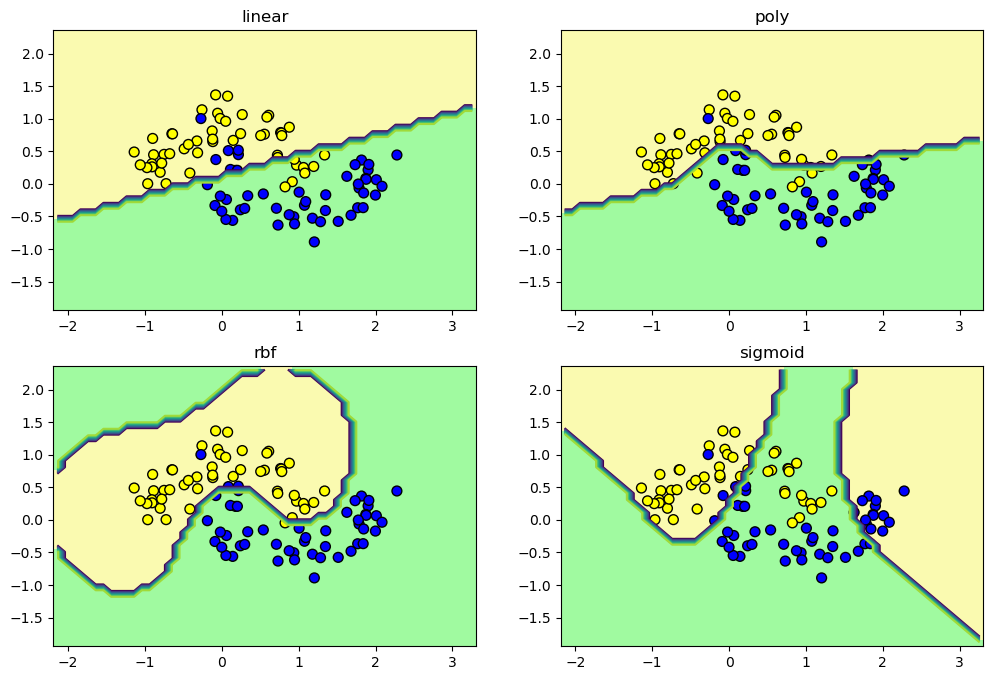

In [15]:
##### el caso del grafico con C=10 fue el que obtuvo los mejores resultados
fig,ax=plt.subplots(2,2,figsize=(12,8))
ax=ax.ravel()
kernels=["linear","poly","rbf","sigmoid"]
for axi, mikernel in zip(ax,kernels):
    svm=SVC(C=10,kernel=mikernel)
    svm.fit(X,y)
    utils.plot_classf_model(X,y,svm,axi,step=0.1,epsilon=1,contour=True)
    axi.set_title(mikernel)

### visualización con los support vectors

In [16]:
X, y = make_blobs(n_samples=200, centers=2, random_state=6)

### kernel lineal

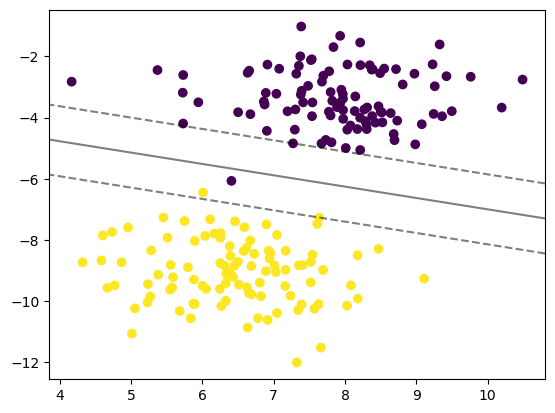

NameError: name 'pca_values' is not defined

In [17]:
svmm = SVC(kernel='linear', C=1) ## medida de regularizacion=1
svmm.fit(X, y)
plt.scatter(X[:,0],X[:,1],c=y)
ax = plt.gca()
xlim = ax.get_xlim()
ylim = ax.get_ylim()
x0 = np.linspace(xlim[0], xlim[1], 100)
y0 = np.linspace(ylim[0], ylim[1], 100)
x1,y1=np.meshgrid(x0,y0)
xy = np.vstack([x1.ravel(), y1.ravel()]).T
z =svmm.decision_function(xy).reshape(y1.shape)
ax.contour(x1, y1, z, colors='k', levels=[-1,0,1], alpha=0.5,
           linestyles=['--','-','--'])
plt.show()
#Define color list
colors = ['blue', 'red', 'green', 'black', 'purple', 'brown']
if len(pca_values[0]) > 6:
    colors=colors*(int(len(pca_values[0])/6)+1)

### penalización extrema

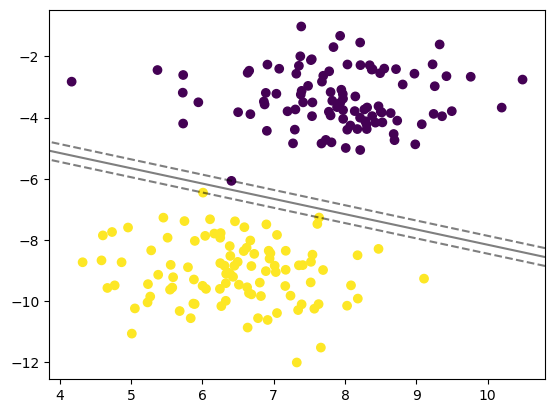

In [18]:
svmm = SVC(kernel='linear', C=100) ## medida de regularizacion=100
svmm.fit(X, y)
plt.scatter(X[:,0],X[:,1],c=y)
ax = plt.gca()
xlim = ax.get_xlim()
ylim = ax.get_ylim()
x0 = np.linspace(xlim[0], xlim[1], 100)
y0 = np.linspace(ylim[0], ylim[1], 100)
x1,y1=np.meshgrid(x0,y0)
xy = np.vstack([x1.ravel(), y1.ravel()]).T
z =svmm.decision_function(xy).reshape(y1.shape)
ax.contour(x1, y1, z, colors='k', levels=[-1,0,1], alpha=0.5,
           linestyles=['--','-','--'])
plt.show()

### kernel sigmoide

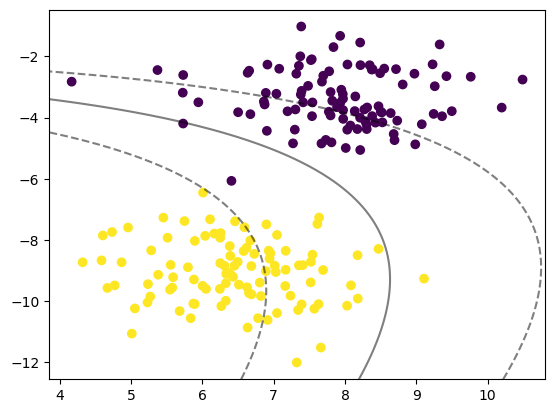

In [19]:
svmm = SVC(kernel='sigmoid', C=1) ## medida de regularizacion=1
svmm.fit(X, y)
plt.scatter(X[:,0],X[:,1],c=y)
ax = plt.gca()
xlim = ax.get_xlim()
ylim = ax.get_ylim()
x0 = np.linspace(xlim[0], xlim[1], 100)
y0 = np.linspace(ylim[0], ylim[1], 100)
x1,y1=np.meshgrid(x0,y0)
xy = np.vstack([x1.ravel(), y1.ravel()]).T
z =svmm.decision_function(xy).reshape(y1.shape)
ax.contour(x1, y1, z, colors='k', levels=[-1,0,1], alpha=0.5,
           linestyles=['--','-','--'])
plt.show()

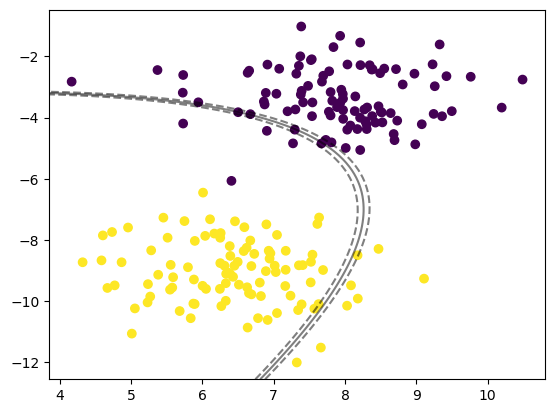

In [20]:
svmm = SVC(kernel='sigmoid', C=100) ## medida de regularizacion=1
svmm.fit(X, y)
plt.scatter(X[:,0],X[:,1],c=y)
ax = plt.gca()
xlim = ax.get_xlim()
ylim = ax.get_ylim()
x0 = np.linspace(xlim[0], xlim[1], 100)
y0 = np.linspace(ylim[0], ylim[1], 100)
x1,y1=np.meshgrid(x0,y0)
xy = np.vstack([x1.ravel(), y1.ravel()]).T
z =svmm.decision_function(xy).reshape(y1.shape)
ax.contour(x1, y1, z, colors='k', levels=[-1,0,1], alpha=0.5,
           linestyles=['--','-','--'])
plt.show()

#### visualización en R3

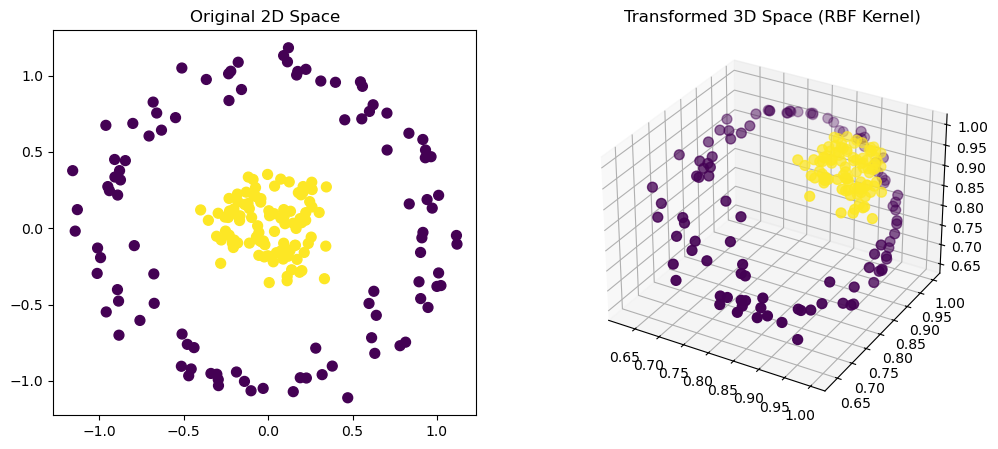

In [21]:
##Visualización kernel trick
from sklearn.datasets import make_circles
from sklearn.svm import SVC
from mpl_toolkits.mplot3d import Axes3D

# Datos que no son linealmente separables
X, y = make_circles(n_samples=200, noise=0.1, factor=0.2, random_state=42)

# Train an SVM classifier with the RBF kernel
svm = SVC(kernel='rbf', C=1, gamma=1/10)
svm.fit(X, y)

# Define el kernel de transformación
def rbf_transform(X, gamma):
    sq_dist = np.sum(X ** 2, axis=1).reshape(-1, 1) + np.sum(X ** 2, axis=1) - 2 * X.dot(X.T)
    return np.exp(-gamma * sq_dist)

# Transform the dataset using the RBF kernel
X_transformed = rbf_transform(X, gamma=svm.gamma)

# Crear gráfico
fig = plt.figure(figsize=(12, 5))

# 2D plot
ax1 = fig.add_subplot(121)
ax1.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', s=50)
ax1.set_title("Original 2D Space")

# 3D plot
ax2 = fig.add_subplot(122, projection='3d')
ax2.scatter(X_transformed[:, 0], X_transformed[:, 1], X_transformed[:, 2], c=y, cmap='viridis', s=50)
ax2.set_title("Transformed 3D Space (RBF Kernel)")

plt.show()

### Ejemplo en Regresión

In [22]:
df = pd.read_csv("boston_housing.csv",delimiter=r"\s+",names=['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'PRICE'])


# hacemos un modelos con las columnas mas importantes
X= df[['RM', 'LSTAT','DIS', 'CRIM', 'AGE', 'INDUS']].values #sólo algunas variables
Y= np.array(df["PRICE"]).reshape(-1, 1)
### cuando usamos svm para regresión es mejor estandarizar los datos , para tener algo similar a la clasificación -1,1
sc_X = StandardScaler()
sc_Y = StandardScaler()
X = sc_X.fit_transform(X)
Y= sc_Y.fit_transform(Y)
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.25,random_state = 42)

In [23]:
svr_model = SVR().fit(X_train,Y_train)
print("svr_model r2 en train,",svr_model.score(X_train,Y_train))
print("svr_model r2 en test,",svr_model.score(X_test,Y_test)) 
y_pred = svr_model.predict(X_test)

svr_model r2 en train, 0.8707302204202482
svr_model r2 en test, 0.7884215257424957


C:\Users\schav\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [24]:
### hiperparametrizamos
model_params={
    "tree_model":{
        "model":SVR(), 
        "params":{
            "C":[.001,.01,.1,1,10,100],
            "kernel":["linear", "poly", "rbf", "sigmoid"],
            'gamma': ['scale', 'auto']
        }
    }
      
}

In [25]:
r2_models=[] # lista para guardar el r2 de cada uno de los modelos
for model_name,mp in model_params.items():

    modelo=GridSearchCV(mp["model"],mp["params"],cv=5,n_jobs=-1,scoring="r2",verbose=0) #evaluamos con r2 y partimos en 3 el conjunto de train
    
    modelo.fit(X_train,Y_train)
    r2_models.append({
        "model":model_name,
        "best_score":modelo.best_score_,
        "best_params":modelo.best_params_
    })

C:\Users\schav\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [26]:
df_r2_models=pd.DataFrame(r2_models).sort_values(by="best_score",ascending=False)
df_r2_models

,model,best_score,best_params
0,tree_model,0.825104,"{'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}"


In [27]:
svr_model = SVR(C=10,kernel="rbf",gamma="scale").fit(X_train,Y_train)
print("svr_model r2 en train,",svr_model.score(X_train,Y_train))
print("svr_model r2 en test,",svr_model.score(X_test,Y_test)) 
y_pred = svr_model.predict(X_test)

svr_model r2 en train, 0.9344204280900797
svr_model r2 en test, 0.8152812156230376


C:\Users\schav\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [28]:
comparacion_estimaciones = pd.DataFrame()
comparacion_estimaciones["PRECIO REAL"] =sc_Y.inverse_transform(np.array(Y_test).reshape(-1, 1)).tolist()
comparacion_estimaciones["PRECIO ESTIMADO"] =sc_Y.inverse_transform(np.array(y_pred).reshape(-1, 1)).tolist() 
comparacion_estimaciones

,PRECIO REAL,PRECIO ESTIMADO
0,[23.6],[27.34648237177738]
1,[32.4],[31.378274700915554]
2,[13.6],[17.70575313651327]
3,[22.8],[23.297429670665498]
4,[16.1],[15.923779155111067]
...,...,...
122,[8.8],[6.308971211978335]
123,[19.2],[19.134573896428783]
124,[25.3],[23.815113660841167]
125,[20.4],[20.78477399481369]


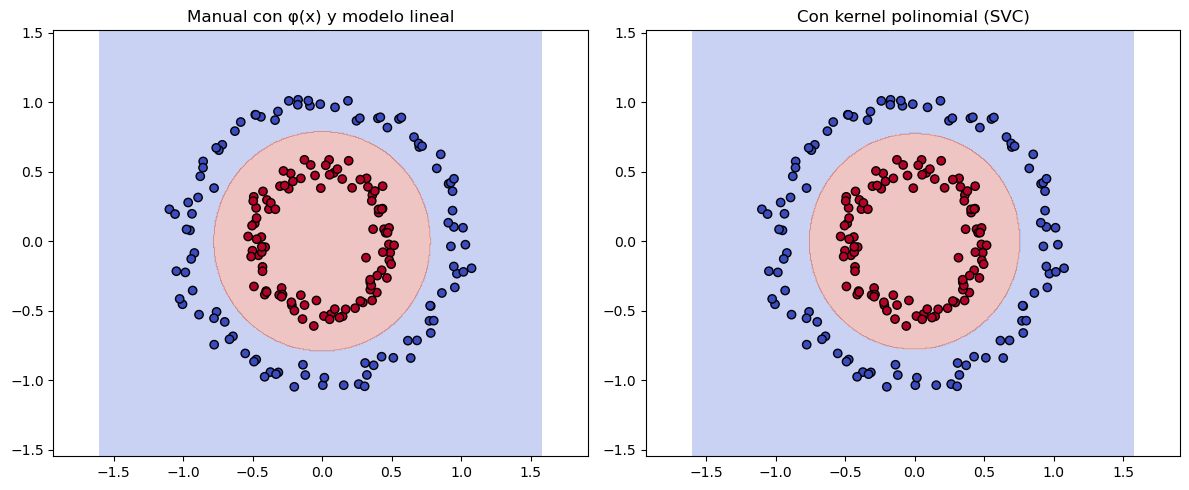

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import make_circles
from sklearn.preprocessing import FunctionTransformer
from sklearn.pipeline import make_pipeline

# 1. Crear conjunto de datos no lineal
X, y = make_circles(n_samples=200, factor=0.5, noise=0.05, random_state=0)

# 2. Transformación explícita manual: phi(x) = [x1^2, sqrt(2)x1x2, x2^2]
def phi_manual(X):
    x1 = X[:, 0]
    x2 = X[:, 1]
    return np.vstack([
        x1**2,
        np.sqrt(2)*x1*x2,
        x2**2
    ]).T

# Transformamos los datos manualmente
X_phi = phi_manual(X)

# 3. Modelo lineal sobre datos transformados manualmente
clf_manual = LogisticRegression().fit(X_phi, y)

# 4. Modelo con sklearn usando kernel polinomial (d=2, coef0=0)
clf_kernel = SVC(kernel='poly', degree=2, coef0=0, C=1.0).fit(X, y)

# 5. Función para graficar fronteras de decisión
def plot_decision_boundary(clf, X, y, transformer=None, title=""):
    x_min, x_max = X[:, 0].min() - .5, X[:, 0].max() + .5
    y_min, y_max = X[:, 1].min() - .5, X[:, 1].max() + .5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 500),
                         np.linspace(y_min, y_max, 500))
    X_grid = np.c_[xx.ravel(), yy.ravel()]
    
    if transformer:
        X_grid_transformed = transformer(X_grid)
    else:
        X_grid_transformed = X_grid
    
    Z = clf.predict(X_grid_transformed).reshape(xx.shape)
    plt.contourf(xx, yy, Z, cmap=plt.cm.coolwarm, alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm, edgecolors='k')
    plt.title(title)
    plt.axis('equal')

# 6. Gráficos comparativos
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plot_decision_boundary(clf_manual, X, y, transformer=phi_manual, title="Manual con φ(x) y modelo lineal")

plt.subplot(1, 2, 2)
plot_decision_boundary(clf_kernel, X, y, transformer=None, title="Con kernel polinomial (SVC)")

plt.tight_layout()
plt.show()

In [2]:
X, y = make_circles(n_samples=100, factor=0.5, noise=0.05, random_state=42)

# 2. Definir kernel polinomial grado 2 manualmente
def polynomial_kernel(X1, X2, degree=2, coef0=0):
    return (X1 @ X2.T + coef0) ** degree

# 3. Calcular la matriz de kernel K para entrenamiento
K_train = polynomial_kernel(X, X)

# 4. Entrenar modelo con kernel precomputado
svc_precomputed = SVC(kernel='precomputed', C=1.0)
svc_precomputed.fit(K_train, y)

# 5. Entrenar modelo con kernel='poly' como referencia
svc_builtin = SVC(kernel='poly', degree=2, coef0=0, C=1.0)
svc_builtin.fit(X, y)

# 6. Predicción y comparación en el conjunto de entrenamiento
y_pred_manual = svc_precomputed.predict(K_train)
y_pred_builtin = svc_builtin.predict(X)

print("¿Predicciones iguales?", np.all(y_pred_manual == y_pred_builtin))

¿Predicciones iguales? True


In [4]:
K_train

array([[7.52397105e-02, 5.37781129e-02, 3.40411341e-03, ...,
        1.54301518e-01, 2.37955634e-02, 2.12401294e-02],
       [5.37781129e-02, 9.05657981e-02, 1.25031497e-02, ...,
        1.64222822e-02, 1.56230934e-04, 6.29979915e-02],
       [3.40411341e-03, 1.25031497e-02, 6.75952711e-02, ...,
        1.57526546e-01, 6.36975902e-02, 2.73312413e-02],
       ...,
       [1.54301518e-01, 1.64222822e-02, 1.57526546e-01, ...,
        9.19880452e-01, 2.48803384e-01, 1.58081972e-03],
       [2.37955634e-02, 1.56230934e-04, 6.36975902e-02, ...,
        2.48803384e-01, 7.92327048e-02, 8.49191887e-03],
       [2.12401294e-02, 6.29979915e-02, 2.73312413e-02, ...,
        1.58081972e-03, 8.49191887e-03, 5.43398375e-02]])

In [5]:
# Nuevos datos (ejemplo: mismos que entrenamiento)
K_test = polynomial_kernel(X, X)  # o nuevos datos en la primera entrada
y_pred = svc_precomputed.predict(K_test)